In [1]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Duffing Calibration with Particle Monte Carlo EM

The preceding filtering and smoothing examples held the stochastic Duffing parameters fixed. This example estimates the parameter vector

$$
\theta=(\alpha,\beta,\delta,s)^{\mathsf T}
$$

from noisy position measurements. The calculation uses particle Monte Carlo expectation-maximization (particle MCEM): each E-step constructs a particle smoothing approximation and draws joint state trajectories, and each M-step holds those trajectories fixed while maximizing their sampled complete-data log-likelihood {cite:p}`wei1990mcem,doucet2001smc`.

Finite particle and trajectory counts make the E-step approximate. An increase of the sampled objective therefore does not guarantee an increase of the exact observed-data likelihood. The independent particle-filter likelihood evaluations and the parameter trajectory below assess this finite calculation; they do not prove convergence.

In [2]:
import importlib.util
import json
import os
import subprocess
import sys
from importlib import metadata

DAX_COMMIT = "084af6da51c95ea0807759022344c3cca07d0a64"
required_packages = {
    "blackjax": "blackjax",
    "diffrax": "diffrax",
    "optax": "optax",
    "seaborn": "seaborn",
}
missing_packages = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *missing_packages]
    )

if importlib.util.find_spec("dax") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-deps",
            f"git+https://github.com/PredictiveScienceLab/dax.git@{DAX_COMMIT}",
        ]
    )
else:
    try:
        direct_url = metadata.distribution("dax").read_text("direct_url.json")
        installed_commit = json.loads(direct_url or "{}").get(
            "vcs_info", {}
        ).get("commit_id")
    except metadata.PackageNotFoundError:
        installed_commit = os.environ.get("DAX_SOURCE_COMMIT")
    if installed_commit != DAX_COMMIT:
        raise RuntimeError(
            "This notebook requires DAX commit " + DAX_COMMIT + "."
        )

In [3]:
import time

import dax
import jax
import jax.numpy as jnp
import jax.random as jr

jax.config.update("jax_enable_x64", True)
key = jr.PRNGKey(0)

## Model and Observations

The stochastic state is $\boldsymbol{X}_t=(X_{1,t},X_{2,t})^{\mathsf T}$, where $X_1$ is position and $X_2$ is a velocity-like state. With $u(t)=\cos(\omega t)$, the Itô model is

$$
\begin{aligned}
dX_{1,t} &= X_{2,t}\,dt+\sigma_x\,dW_{1,t},\\
dX_{2,t} &= [\gamma u(t)-\delta X_{2,t}-\alpha X_{1,t}-\beta X_{1,t}^3]dt
           +\sigma_v\,dW_{2,t}.
\end{aligned}
$$

The Brownian motions $W_1$ and $W_2$ are independent. Because $\sigma_x>0$, the position paths are nondifferentiable and $X_2$ is not literally $dX_1/dt$ pathwise. At the positive observation times $t_n=n\Delta t$,

$$
Y_n=X_{1,t_n}+s\varepsilon_n,
\qquad
\varepsilon_n\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,1),
$$

where the observation errors are independent of the Brownian motions and the initial state. The calculation permits $\alpha$, $\beta$, and $\delta$ to vary over $\mathbb{R}$ and constrains the estimated observation standard deviation to satisfy $s>0$. It fixes $\omega$, $\gamma$, $\sigma_x$, $\sigma_v$, and the initial-state law.

The numerical experiment uses the same two-noise Duffing model as the filtering and smoothing examples. The synthetic path starts from $\boldsymbol{X}_0=(1,0)^{\mathsf T}$, while inference uses the broader prior $\boldsymbol{X}_0\sim\mathcal{N}(\boldsymbol{0},I_2)$. With $\Delta t=0.1$, the calibration record contains $T=200$ transitions through $t=20$; the remaining path is held out for prediction.

In [4]:
class DuffingControl(dax.ControlFunction):
    omega: jax.Array

    def __init__(self, omega):
        self.omega = jnp.asarray(omega)

    def _eval(self, t):
        omega = jax.lax.stop_gradient(self.omega)
        return jnp.cos(omega * t)


class Duffing(dax.StochasticDifferentialEquation):
    alpha: jax.Array
    beta: jax.Array
    delta: jax.Array
    gamma: jax.Array
    log_sigma_x: jax.Array
    log_sigma_v: jax.Array

    def __init__(
        self, alpha, beta, gamma, delta, sigma_x, sigma_v, control
    ):
        super().__init__(control_function=control)
        self.alpha = jnp.asarray(alpha)
        self.beta = jnp.asarray(beta)
        self.delta = jnp.asarray(delta)
        self.gamma = jnp.asarray(gamma)
        self.log_sigma_x = jnp.log(jnp.asarray(sigma_x))
        self.log_sigma_v = jnp.log(jnp.asarray(sigma_v))

    @property
    def sigma_x(self):
        return jnp.exp(self.log_sigma_x)

    @property
    def sigma_v(self):
        return jnp.exp(self.log_sigma_v)

    def drift(self, x, control):
        gamma = jax.lax.stop_gradient(self.gamma)
        return jnp.array(
            [
                x[1],
                gamma * control
                - self.delta * x[1]
                - self.alpha * x[0]
                - self.beta * x[0] ** 3,
            ]
        )

    def diffusion(self, x, control):
        del x, control
        return jnp.array(
            [
                jax.lax.stop_gradient(self.sigma_x),
                jax.lax.stop_gradient(self.sigma_v),
            ]
        )


In [5]:
omega = 1.2
alpha_true = -1.0
beta_true = 1.0
delta_true = 0.3
gamma = 0.5
sigma_x = 0.01
sigma_v = 0.05
s_true = 0.1

control_function = DuffingControl(omega)
true_sde = Duffing(
    alpha_true,
    beta_true,
    gamma,
    delta_true,
    sigma_x,
    sigma_v,
    control_function,
)
true_x0 = jnp.array([1.0, 0.0])
observation_function = dax.SingleStateSelector(0)
true_likelihood = dax.GaussianLikelihood(
    s_true, observation_function
)

t0 = 0.0
t1 = 40.0
dt = 0.1
key, path_key, observation_key = jr.split(key, 3)
solution = true_sde.sample_path(
    path_key, t0, t1, true_x0, dt=dt, dt0=0.05
)
xs = solution.ys
ts = solution.ts
controls = control_function(ts)

observation_keys = jr.split(observation_key, xs.shape[0] - 1)
observations = true_likelihood.sample(
    xs[1:], controls[:-1], observation_keys
)

num_train_transitions = 200
controls_train = controls[:num_train_transitions]
observations_train = observations[:num_train_transitions]
ts_train_state = ts[: num_train_transitions + 1]
ts_train_observation = ts[1 : num_train_transitions + 1]

initial_distribution = dax.DiagonalGaussian(
    jnp.zeros(2), jnp.ones(2)
)


def make_ssm(alpha, beta, delta, observation_standard_deviation):
    sde = Duffing(
        alpha,
        beta,
        gamma,
        delta,
        sigma_x,
        sigma_v,
        control_function,
    )
    likelihood = dax.GaussianLikelihood(
        observation_standard_deviation, observation_function
    )
    return dax.StateSpaceModel(
        initial_distribution,
        dax.EulerMaruyama(sde, dt=dt),
        likelihood,
    )

## Fixed-Sample M-Step

At outer iteration $m$, the filter and smoother use $\theta^{(m)}$ to draw $M$ joint trajectories. The M-step holds those trajectories fixed. For trajectory $j$, write $X_n^{(j)}=X_{1,t_n}^{(j)}$, $V_n^{(j)}=X_{2,t_n}^{(j)}$, and $u_n=u(t_n)$; with $\xi_n^{(j)}$ standard normal, the Euler--Maruyama velocity update gives

$$
V_{n+1}^{(j)}
=V_n^{(j)}+
[\gamma u_n-\delta V_n^{(j)}-\alpha X_n^{(j)}-\beta(X_n^{(j)})^3]\Delta t
+\sigma_v\sqrt{\Delta t}\,\xi_n^{(j)}.
$$

Define

$$
r_n^{(j)}=V_n^{(j)}+\gamma u_n\Delta t-V_{n+1}^{(j)},
\qquad
\boldsymbol{z}_n^{(j)}=
\Delta t\begin{bmatrix}X_n^{(j)}&(X_n^{(j)})^3&V_n^{(j)}\end{bmatrix}^{\mathsf T}.
$$

Because $\sigma_v$ is fixed, maximizing the sampled transition objective is the least-squares problem

$$
\min_{\alpha,\beta,\delta}
\sum_{j=1}^{M}\sum_{n=0}^{T-1}
\left[r_n^{(j)}-(\boldsymbol{z}_n^{(j)})^{\mathsf T}
\begin{bmatrix}\alpha&\beta&\delta\end{bmatrix}^{\mathsf T}
\right]^2.
$$

The observation-scale update is

$$
s^2=
\frac{1}{MT}
\sum_{j=1}^{M}\sum_{n=0}^{T-1}
\left(y_{n+1}-X_{n+1}^{(j)}\right)^2.
$$

These updates maximize the fixed sampled objective. A new particle E-step changes that random objective at the next outer iteration.

In [6]:
def sampled_complete_log_likelihood(
    model, trajectories, controls, observations
):
    return jnp.mean(
        model.log_prob(trajectories.samples, controls, observations)
    )


def maximize_sampled_objective(
    trajectories, controls, observations
):
    samples = trajectories.samples
    position = samples[:, :-1, 0]
    velocity = samples[:, :-1, 1]
    velocity_next = samples[:, 1:, 1]
    controls_matrix = jnp.broadcast_to(
        controls[None, :], position.shape
    )

    design = dt * jnp.stack(
        [position, position**3, velocity], axis=-1
    )
    response = (
        velocity
        + gamma * controls_matrix * dt
        - velocity_next
    )
    coefficients = jnp.linalg.lstsq(
        design.reshape(-1, 3), response.reshape(-1), rcond=None
    )[0]

    observation_residual = (
        observations[None, :] - samples[:, 1:, 0]
    )
    observation_standard_deviation = jnp.sqrt(
        jnp.mean(observation_residual**2)
    )
    return make_ssm(
        coefficients[0],
        coefficients[1],
        coefficients[2],
        observation_standard_deviation,
    )


def parameter_vector(model):
    return jnp.array(
        [
            model.transition.sde.alpha,
            model.transition.sde.beta,
            model.transition.sde.delta,
            model.likelihood.sigma,
        ]
    )

## Particle MCEM Calculation

The initial guess is $(\alpha,\beta,\delta,s)=(0,0,0,2)$. Each of the 75 outer iterations uses 1,000 filtering particles and 64 backward-sampled trajectories. The 75-iteration run makes the approach to a stable parameter region visible, while the 64-trajectory sample reduces the iteration-to-iteration Monte Carlo variation. The random-number stream is split explicitly between filtering, smoothing, likelihood assessment, and prediction.

In [7]:
num_particles = 1_000
num_smoothing_trajectories = 64
num_em_iterations = 75

particle_filter = dax.BootstrapFilter(
    num_particles=num_particles
)
particle_smoother = dax.BootstrapSmoother(
    num_smoothing_trajectories
)

ssm_initial = make_ssm(0.0, 0.0, 0.0, 2.0)
ssm = ssm_initial
parameter_history = [parameter_vector(ssm)]
likelihood_history = []
sampled_q_gains = []

start_time = time.perf_counter()
for iteration in range(num_em_iterations):
    key, filter_key, smoother_key = jr.split(key, 3)
    filtering_particles, log_likelihood = particle_filter.filter(
        ssm, controls_train, observations_train, filter_key
    )
    trajectories = particle_smoother.smooth(
        ssm,
        filtering_particles,
        controls_train,
        observations_train,
        smoother_key,
    )
    q_before = sampled_complete_log_likelihood(
        ssm, trajectories, controls_train, observations_train
    )
    candidate_ssm = maximize_sampled_objective(
        trajectories, controls_train, observations_train
    )
    q_after = sampled_complete_log_likelihood(
        candidate_ssm,
        trajectories,
        controls_train,
        observations_train,
    )
    if float(q_after) + 1e-8 < float(q_before):
        raise RuntimeError("The analytic M-step decreased the sampled objective.")

    likelihood_history.append(log_likelihood)
    sampled_q_gains.append(q_after - q_before)
    ssm = candidate_ssm
    parameter_history.append(parameter_vector(ssm))

key, final_filter_key = jr.split(key)
filtering_particles, final_log_likelihood = particle_filter.filter(
    ssm, controls_train, observations_train, final_filter_key
)
likelihood_history.append(final_log_likelihood)

num_likelihood_replicates = 5
key, initial_assessment_key, final_assessment_key = jr.split(key, 3)
initial_assessment_keys = jr.split(
    initial_assessment_key, num_likelihood_replicates
)
final_assessment_keys = jr.split(
    final_assessment_key, num_likelihood_replicates
)
initial_likelihood_replicates = jnp.array(
    [
        particle_filter.filter(
            ssm_initial, controls_train, observations_train, replicate_key
        )[1]
        for replicate_key in initial_assessment_keys
    ]
)
final_likelihood_replicates = jnp.array(
    [
        particle_filter.filter(
            ssm, controls_train, observations_train, replicate_key
        )[1]
        for replicate_key in final_assessment_keys
    ]
)

elapsed_seconds = time.perf_counter() - start_time
parameter_history = jnp.stack(parameter_history)
likelihood_history = jnp.stack(likelihood_history)
sampled_q_gains = jnp.stack(sampled_q_gains)
convergence_window = 10
final_window = parameter_history[-convergence_window:]
previous_window = parameter_history[
    -2 * convergence_window : -convergence_window
]
final_window_mean = jnp.mean(final_window, axis=0)
final_window_sd = jnp.std(final_window, axis=0, ddof=1)
maximum_window_shift = jnp.max(
    jnp.abs(
        final_window_mean - jnp.mean(previous_window, axis=0)
    )
)

print(
    "Final estimates: "
    f"alpha={float(parameter_history[-1, 0]):.3f}, "
    f"beta={float(parameter_history[-1, 1]):.3f}, "
    f"delta={float(parameter_history[-1, 2]):.3f}, "
    f"s={float(parameter_history[-1, 3]):.3f}"
)
print(
    "Generating values: "
    f"alpha={alpha_true:.3f}, beta={beta_true:.3f}, "
    f"delta={delta_true:.3f}, s={s_true:.3f}"
)
print(
    "Last-10 parameter means: "
    f"alpha={float(final_window_mean[0]):.3f}, "
    f"beta={float(final_window_mean[1]):.3f}, "
    f"delta={float(final_window_mean[2]):.3f}, "
    f"s={float(final_window_mean[3]):.3f}"
)
print(
    "Last-10 parameter sample SDs: "
    f"alpha={float(final_window_sd[0]):.3f}, "
    f"beta={float(final_window_sd[1]):.3f}, "
    f"delta={float(final_window_sd[2]):.3f}, "
    f"s={float(final_window_sd[3]):.4f}"
)
print(
    "Largest change between the last two 10-iteration means: "
    f"{float(maximum_window_shift):.4f}"
)
print(
    "Smallest fixed-sample objective gain: "
    f"{float(jnp.min(sampled_q_gains)):.3f}"
)
print(
    "Independent particle-likelihood estimates, mean +/- sample SD "
    f"({num_likelihood_replicates} runs): "
    f"initial={float(jnp.mean(initial_likelihood_replicates)):.1f} +/- "
    f"{float(jnp.std(initial_likelihood_replicates, ddof=1)):.1f}; "
    f"final={float(jnp.mean(final_likelihood_replicates)):.1f} +/- "
    f"{float(jnp.std(final_likelihood_replicates, ddof=1)):.1f}"
)
print(f"Elapsed particle-MCEM time: {elapsed_seconds:.1f} s")

print("MCEM_DIAGNOSTICS " + json.dumps({
    "final": parameter_history[-1].tolist(),
    "window_mean": final_window_mean.tolist(),
    "window_sd": final_window_sd.tolist(),
    "window_shift": float(maximum_window_shift),
    "initial_loglik_mean": float(jnp.mean(initial_likelihood_replicates)),
    "initial_loglik_sd": float(jnp.std(initial_likelihood_replicates, ddof=1)),
    "final_loglik_mean": float(jnp.mean(final_likelihood_replicates)),
    "final_loglik_sd": float(jnp.std(final_likelihood_replicates, ddof=1)),
}, sort_keys=True))


Final estimates: alpha=-0.984, beta=0.955, delta=0.406, s=0.101
Generating values: alpha=-1.000, beta=1.000, delta=0.300, s=0.100
Last-10 parameter means: alpha=-0.989, beta=0.961, delta=0.400, s=0.101
Last-10 parameter sample SDs: alpha=0.008, beta=0.006, delta=0.006, s=0.0006
Largest change between the last two 10-iteration means: 0.0014
Smallest fixed-sample objective gain: 0.014
Independent particle-likelihood estimates, mean +/- sample SD (5 runs): initial=-342.1 +/- 4.6; final=156.7 +/- 1.3
Elapsed particle-MCEM time: 15.1 s
MCEM_DIAGNOSTICS {"final": [-0.9835819266751463, 0.9549663992048181, 0.4063358223027525, 0.1014274025055034], "final_loglik_mean": 156.73216143228086, "final_loglik_sd": 1.3329960048616816, "initial_loglik_mean": -342.0614776644404, "initial_loglik_sd": 4.577194824498325, "window_mean": [-0.9886348772269035, 0.9610682330045579, 0.3997907532931093, 0.10064102707778133], "window_sd": [0.00834087404433657, 0.006086255083523659, 0.006396232184600977, 0.0006097854

The sampled complete-data objective increases in every M-step because the trajectories remain fixed while the closed-form update is computed. The particle estimate of the observed-data log likelihood answers a different question and remains noisy across outer iterations.

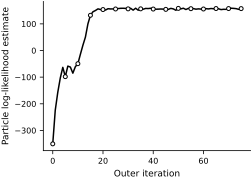

In [8]:
fig, ax = new_figure(size="half_standard")
iterations = jnp.arange(likelihood_history.shape[0])
ax.plot(
    iterations,
    likelihood_history,
    color="black",
    linestyle="-",
    marker="o",
    markerfacecolor="white",
    markeredgecolor="black",
    markevery=5,
)
ax.set_xlabel("Outer iteration")
ax.set_ylabel("Particle log-likelihood estimate")
finalize_axes(ax)
plt.show()

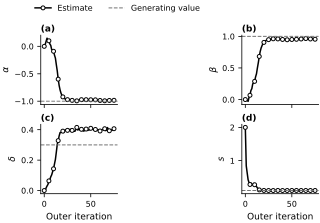

In [9]:
fig, axes = new_figure(
    size="full_standard", nrows=2, ncols=2, sharex=True
)
parameter_names = [r"$\alpha$", r"$\beta$", r"$\delta$", r"$s$"]
true_parameters = jnp.array(
    [alpha_true, beta_true, delta_true, s_true]
)

for parameter_index, ax in enumerate(axes.ravel()):
    ax.plot(
        jnp.arange(parameter_history.shape[0]),
        parameter_history[:, parameter_index],
        color="black",
        linestyle="-",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markevery=5,
        label="Estimate",
    )
    ax.axhline(
        true_parameters[parameter_index],
        color="0.45",
        linestyle="--",
        linewidth=1.0,
        label="Generating value",
    )
    ax.set_ylabel(parameter_names[parameter_index])

axes[1, 0].set_xlabel("Outer iteration")
axes[1, 1].set_xlabel("Outer iteration")
axes[0, 0].legend(
    loc="lower center", bbox_to_anchor=(1.0, 1.22), ncol=2
)
label_panels(axes, x=0.0, y=1.02, va="bottom")
finalize_axes(axes)
plt.show()

The parameter trajectories in {numref}`fig-duffing-pmcem-parameters` settle after the initial transient. Over the final ten iterations, their means are $(-0.989,0.961,0.400,0.101)$ and their sample standard deviations are $(0.008,0.006,0.006,0.0006)$. The largest componentwise change between the final two ten-iteration means is $0.0014$. These diagnostics show numerical stabilization at the chosen Monte Carlo resolution; they do not prove convergence to the exact maximum.

The final candidate is $(\widehat\alpha,\widehat\beta,\widehat\delta,\widehat s)=(-0.984,0.955,0.406,0.101)$. Across five independent particle-filter runs, the mean log-likelihood estimate changes from $-342.1$ at the initial parameters to $156.7$ at the final candidate; the sample standard deviations are $4.6$ and $1.3$, respectively. This comparison supplies additional evidence of numerical improvement.

The estimate is one finite-data, finite-particle result. Comparison with the generating values is a useful synthetic-data check: $\alpha$, $\beta$, and $s$ are recovered closely, whereas $\widehat\delta\approx0.41$ differs visibly from the generating value $0.3$. A finite-sample maximum-likelihood estimate need not equal the generating values. Repeated random seeds and larger particle and trajectory counts are needed to assess Monte Carlo stability.

The transition objective is the likelihood of the Euler--Maruyama model with step $\Delta t=0.1$. It is not automatically the exact continuous-time SDE likelihood; changing the inference step or transition approximation can change the estimate.

## State Reconstruction and Prediction

The final parameter vector is held fixed while the training interval is filtered again. The forecast begins from the filtering distribution at $t=20$ and receives no later observations. Its pointwise intervals include filtering uncertainty and future process noise conditional on the fitted parameters. They exclude parameter uncertainty and future observation noise. The resulting filtering and predictive summaries appear in {numref}`fig-duffing-pmcem-forecast`.

Training filtering-median RMSE: position=0.077, velocity-like state=0.094
Pointwise held-out latent-state coverage: position=0.975, velocity-like state=0.965
MCEM_FORECAST {"coverage": [0.9749999642372131, 0.9649999737739563], "rmse": [0.07683524108460321, 0.09379855619110877]}


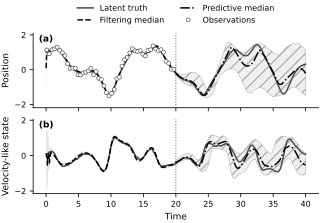

In [10]:
key, interval_key, forecast_interval_key, resampling_key, propagation_key = jr.split(key, 5)
filter_lower, filter_median, filter_upper = (
    filtering_particles.get_credible_interval(interval_key)
)

ts_forecast = ts[num_train_transitions:]
controls_forecast = controls[num_train_transitions:-1]
start_particles = filtering_particles[-1].resample(
    resampling_key
).particles
step_keys = jr.split(propagation_key, controls_forecast.shape[0])


def forecast_step(particles, control_and_key):
    control, step_key = control_and_key
    particle_keys = jr.split(step_key, particles.shape[0])
    particles_next = ssm.transition.sample(
        particles, control, particle_keys
    )
    return particles_next, particles_next


_, future_particles = jax.lax.scan(
    forecast_step,
    start_particles,
    (controls_forecast, step_keys),
)
forecast_particles = jnp.concatenate(
    [start_particles[None, :, :], future_particles], axis=0
)
forecast_pa = dax.TrajectoryParticleApproximation(
    forecast_particles, resampled=True
)
forecast_lower, forecast_median, forecast_upper = (
    forecast_pa.get_credible_interval(forecast_interval_key)
)

training_truth = xs[: num_train_transitions + 1]
training_rmse = jnp.sqrt(
    jnp.mean((filter_median - training_truth) ** 2, axis=0)
)
held_out_truth = xs[num_train_transitions + 1 :]
forecast_coverage = jnp.mean(
    (held_out_truth >= forecast_lower[1:])
    & (held_out_truth <= forecast_upper[1:]),
    axis=0,
)

print(
    "Training filtering-median RMSE: "
    f"position={float(training_rmse[0]):.3f}, "
    f"velocity-like state={float(training_rmse[1]):.3f}"
)
print(
    "Pointwise held-out latent-state coverage: "
    f"position={float(forecast_coverage[0]):.3f}, "
    f"velocity-like state={float(forecast_coverage[1]):.3f}"
)

print("MCEM_FORECAST " + json.dumps({
    "rmse": training_rmse.tolist(),
    "coverage": forecast_coverage.tolist(),
}, sort_keys=True))

fig, axes = new_figure(
    size="full_standard", nrows=2, ncols=1, sharex=True
)
for state_index, ax in enumerate(axes):
    ax.fill_between(
        ts_train_state,
        filter_lower[:, state_index],
        filter_upper[:, state_index],
        facecolor="0.90",
        edgecolor="none",
    )
    ax.fill_between(
        ts_forecast,
        forecast_lower[:, state_index],
        forecast_upper[:, state_index],
        facecolor="0.94",
        edgecolor="0.60",
        linewidth=0.4,
        hatch="//",
    )
    ax.plot(
        ts,
        xs[:, state_index],
        color="0.30",
        linestyle="-",
        label="Latent truth" if state_index == 0 else None,
    )
    ax.plot(
        ts_train_state,
        filter_median[:, state_index],
        color="black",
        linestyle="--",
        label="Filtering median" if state_index == 0 else None,
    )
    ax.plot(
        ts_forecast,
        forecast_median[:, state_index],
        color="black",
        linestyle="-.",
        label="Predictive median" if state_index == 0 else None,
    )
    ax.axvline(
        ts[num_train_transitions],
        color="0.35",
        linestyle=":",
        linewidth=1.0,
    )

axes[0].plot(
    ts_train_observation,
    observations_train,
    linestyle="none",
    marker="o",
    markevery=4,
    markerfacecolor="white",
    markeredgecolor="0.35",
    markeredgewidth=0.7,
    label="Observations",
)
axes[0].set_ylabel("Position")
axes[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Velocity-like state")
label_panels(axes)
finalize_axes(axes)
plt.show()

The filtering-median root-mean-square errors are $0.077$ for position and $0.094$ for the velocity-like state. The held-out latent path lies inside its pointwise predictive interval at $97.5\%$ and $96.5\%$ of the forecast times, respectively. The filtering reconstruction tests the fitted model on the observations used for estimation. The held-out forecast is stricter: no observation after the cutoff recenters the state. Coverage of one simulated path is a diagnostic, not a calibration guarantee.

## Computational Cost

For $N$ particles, $M$ backward trajectories, and $T$ observations, each bootstrap-filter pass costs $O(NT)$. The backward simulator used here evaluates $N$ transition densities at every time for each trajectory, so one E-step costs $O(MNT)$. The closed-form M-step costs $O(MT)$. The measured runtime above depends on the JAX compilation cache and hardware.

## Exercises

1. Repeat the calculation with several random seeds. Compare the parameter estimates and independent particle-likelihood estimates.
2. Increase the particle count $N$ and smoothing-trajectory count $M$ separately. Determine which change most reduces the variability of each parameter estimate.
3. Change the initial parameter vector while holding the synthetic data fixed. Identify initializations that reach materially different candidate estimates.
4. Generate and fit data at smaller values of $\Delta t$. Separate changes caused by a finer observation record from changes caused by the Euler--Maruyama transition approximation.

Particle MCEM supplies a parameter point estimate. The next subsection develops particle Markov chain Monte Carlo, which represents parameter uncertainty with posterior samples.